> Proyecto desarrollado dentro de **@PatronesLab** — análisis de datos abiertos con foco en entender el mundo que nos rodea.


# Pasajeros por compañía — Baleares (2024–2025)

## 📌 Fuente de datos y consideraciones

Los datos utilizados en este notebook provienen de **AENA – Estadísticas de tráfico aeroportuario**, publicados como datos abiertos a través del portal oficial de AENA (https://www.aena.es/es/estadisticas/inicio.html).

El análisis se centra en los aeropuertos de **Palma de Mallorca, Ibiza y Menorca**, considerados como `aeropuertos_base` según la definición oficial de AENA.

Se respetan estrictamente las definiciones de AENA:
- **Aeropuerto base**: aeropuerto de referencia estadística.
- **Aeropuerto escala**: aeropuerto en el que el pasajero embarca o desembarca.
- **Movimiento**:
  - `LLEGADA`: vuelo que llega al aeropuerto base desde una escala.
  - `SALIDA`: vuelo que parte del aeropuerto base hacia una escala.
- **Pasajeros_totales**: suma de pasajeros y tránsitos.

Todas las métricas de pasajeros se calculan exclusivamente con `pasajeros_totales`.

### Consideraciones metodológicas
- Los datos no permiten identificar el origen o destino final del pasajero cuando existen escalas; el análisis se interpreta como tráfico observado en los aeropuertos base.
- No se filtra ningún registro por tipo de servicio o clase de tráfico, para preservar la integridad estadística.
- Se eliminaron únicamente registros sin actividad real (valores cero en todas las métricas operativas).
- El campo `Mes` fue normalizado a fecha (`YYYY-MM-01`) para permitir agregaciones temporales consistentes.
- Las visualizaciones geográficas utilizan coordenadas de aeropuertos obtenidas de fuentes open data, con fines exclusivamente visuales.

Este notebook tiene un enfoque descriptivo y exploratorio, orientado a análisis reproducible y comunicación visual.

---



In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import plotly.graph_objects as go

# Parámetros.
YEARS = [2024, 2025]
MESES_ALTA = [5, 6, 7, 8, 9]  # Definición de temporada alta (mayo–septiembre)

AEROPUERTOS_BASE_BALEARES = ["PALMA DE MALLORCA", "IBIZA", "MENORCA"]
MOVIMIENTOS = ["LLEGADA", "SALIDA"]

def pick_col(df: pd.DataFrame, candidates: list[str]) -> str:
    """Devuelve la primera columna existente en `df` dentro de `candidates`."""
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"No encuentro ninguna de estas columnas: {candidates}")

def fmt_short(x: float) -> str:
    """Formatea números grandes (K/M) para etiquetas de gráficos."""
    x = float(x)
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.2f}M"
    if abs(x) >= 1_000:
        return f"{x/1_000:.1f}K"
    return f"{x:.0f}"


## 1. Carga e inspección rápida

In [5]:
file_path = Path("../data/Pasajeros-por-Compañía_2024_2025.xlsx")
df = pd.read_excel(file_path, engine="openpyxl")

df.head()


,Año,Aeropuerto Base,Clase,Compañía,Grupo Compañía,Mes,Movimiento,País,Servicio,Tipo Avión,Tipo Tráfico,Kg Correo,Mercancías,Mercancías Totales,Mercancías Tránsito,Pasajeros,Pasajeros Totales,Transitos
0,2025,ADOLFO SUÁREZ MADRID-BARAJAS,NACIONAL,AIR EUROPA,AIR EUROPA,Agosto de 2025,LLEGADA,ESPAÑA,REGULAR,BOEING 737-800 (WINGLETS) PASSENGER,COMERCIAL,8001,44906,44906,0,170721,170721,0
1,2025,BARCELONA-EL PRAT J.T.,NACIONAL,"VUELING AIRLINES, S.A.","VUELING AIRLINES, S.A.",Octubre de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A320 (SHARKLETS),COMERCIAL,4,1794,1794,0,167696,167696,0
2,2025,BARCELONA-EL PRAT J.T.,NACIONAL,"VUELING AIRLINES, S.A.","VUELING AIRLINES, S.A.",Agosto de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A320 (SHARKLETS),COMERCIAL,0,1380,1380,0,167099,167099,0
3,2025,BARCELONA-EL PRAT J.T.,NACIONAL,"VUELING AIRLINES, S.A.","VUELING AIRLINES, S.A.",Julio de 2025,SALIDA,ESPAÑA,REGULAR,AIRBUS A320 (SHARKLETS),COMERCIAL,3,6183,6183,0,165307,165307,0
4,2025,BARCELONA-EL PRAT J.T.,NACIONAL,"VUELING AIRLINES, S.A.","VUELING AIRLINES, S.A.",Septiembre de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A320 (SHARKLETS),COMERCIAL,0,1976,1976,0,164852,164852,0


In [6]:
df.shape


(294090, 18)

In [7]:
df.columns


Index(['Año', 'Aeropuerto Base', 'Clase', 'Compañía', 'Grupo Compañía', 'Mes',
       'Movimiento', 'País', 'Servicio', 'Tipo Avión', 'Tipo Tráfico',
       'Kg Correo', 'Mercancías', 'Mercancías Totales', 'Mercancías Tránsito',
       'Pasajeros', 'Pasajeros Totales', 'Transitos'],
      dtype='object')

## 2. Preparación y limpieza

In [8]:
df.columns = (df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.head(10)


,año,aeropuerto_base,clase,compañía,grupo_compañía,mes,movimiento,país,servicio,tipo_avión,tipo_tráfico,kg_correo,mercancías,mercancías_totales,mercancías_tránsito,pasajeros,pasajeros_totales,transitos
0,2025,ADOLFO SUÁREZ MADRID-BARAJAS,NACIONAL,AIR EUROPA,AIR EUROPA,Agosto de 2025,LLEGADA,ESPAÑA,REGULAR,BOEING 737-800 (WINGLETS) PASSENGER,COMERCIAL,8001,44906,44906,0,170721,170721,0
1,2025,BARCELONA-EL PRAT J.T.,NACIONAL,"VUELING AIRLINES, S.A.","VUELING AIRLINES, S.A.",Octubre de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A320 (SHARKLETS),COMERCIAL,4,1794,1794,0,167696,167696,0
2,2025,BARCELONA-EL PRAT J.T.,NACIONAL,"VUELING AIRLINES, S.A.","VUELING AIRLINES, S.A.",Agosto de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A320 (SHARKLETS),COMERCIAL,0,1380,1380,0,167099,167099,0
3,2025,BARCELONA-EL PRAT J.T.,NACIONAL,"VUELING AIRLINES, S.A.","VUELING AIRLINES, S.A.",Julio de 2025,SALIDA,ESPAÑA,REGULAR,AIRBUS A320 (SHARKLETS),COMERCIAL,3,6183,6183,0,165307,165307,0
4,2025,BARCELONA-EL PRAT J.T.,NACIONAL,"VUELING AIRLINES, S.A.","VUELING AIRLINES, S.A.",Septiembre de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A320 (SHARKLETS),COMERCIAL,0,1976,1976,0,164852,164852,0
5,2025,ADOLFO SUÁREZ MADRID-BARAJAS,NACIONAL,AIR EUROPA,AIR EUROPA,Julio de 2025,SALIDA,ESPAÑA,REGULAR,BOEING 737-800 (WINGLETS) PASSENGER,COMERCIAL,0,94222,94222,0,163653,163653,0
6,2025,BARCELONA-EL PRAT J.T.,NACIONAL,"VUELING AIRLINES, S.A.","VUELING AIRLINES, S.A.",Agosto de 2025,SALIDA,ESPAÑA,REGULAR,AIRBUS A320 (SHARKLETS),COMERCIAL,0,6011,6011,0,163606,163606,0
7,2024,BARCELONA-EL PRAT J.T.,NACIONAL,"VUELING AIRLINES, S.A.","VUELING AIRLINES, S.A.",Agosto de 2024,LLEGADA,ESPAÑA,REGULAR,AIRBUS A320 (SHARKLETS),COMERCIAL,7,3041,3041,0,163572,163572,0
8,2024,ADOLFO SUÁREZ MADRID-BARAJAS,NACIONAL,AIR EUROPA,AIR EUROPA,Julio de 2024,SALIDA,ESPAÑA,REGULAR,BOEING 737-800 (WINGLETS) PASSENGER,COMERCIAL,0,106310,106310,0,163098,163098,0
9,2025,ADOLFO SUÁREZ MADRID-BARAJAS,NACIONAL,AIR EUROPA,AIR EUROPA,Septiembre de 2025,LLEGADA,ESPAÑA,REGULAR,BOEING 737-800 (WINGLETS) PASSENGER,COMERCIAL,14366,47316,47316,0,162119,162119,0


### 2.0 Filtrado geográfico
Se filtra a *aeropuerto_base* en Baleares (Palma, Ibiza, Menorca).

In [9]:
df_baleares = df[df["aeropuerto_base"].isin(AEROPUERTOS_BASE_BALEARES)].copy()

df_baleares.shape


(54142, 18)

In [10]:
df_baleares.head(-10)


,año,aeropuerto_base,clase,compañía,grupo_compañía,mes,movimiento,país,servicio,tipo_avión,tipo_tráfico,kg_correo,mercancías,mercancías_totales,mercancías_tránsito,pasajeros,pasajeros_totales,transitos
120,2025,PALMA DE MALLORCA,UE SCHENGEN,EUROWINGS GMBH,LUFTHANSA GROUP,Julio de 2025,LLEGADA,ALEMANIA,REGULAR,AIRBUS A320 PASSENGER,COMERCIAL,0,90,90,0,125373,125373,0
126,2024,PALMA DE MALLORCA,UE SCHENGEN,EUROWINGS GMBH,LUFTHANSA GROUP,Julio de 2024,LLEGADA,ALEMANIA,REGULAR,AIRBUS A320 PASSENGER,COMERCIAL,0,0,0,0,124669,124669,0
131,2025,PALMA DE MALLORCA,UE SCHENGEN,EUROWINGS GMBH,LUFTHANSA GROUP,Octubre de 2025,SALIDA,ALEMANIA,REGULAR,AIRBUS A320 PASSENGER,COMERCIAL,0,14,14,0,123389,123389,0
135,2025,PALMA DE MALLORCA,UE SCHENGEN,EUROWINGS GMBH,LUFTHANSA GROUP,Agosto de 2025,SALIDA,ALEMANIA,REGULAR,AIRBUS A320 PASSENGER,COMERCIAL,0,244,244,0,122202,122202,0
146,2025,PALMA DE MALLORCA,UE SCHENGEN,EUROWINGS GMBH,LUFTHANSA GROUP,Agosto de 2025,LLEGADA,ALEMANIA,REGULAR,AIRBUS A320 PASSENGER,COMERCIAL,0,244,244,0,119047,119047,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291795,2024,PALMA DE MALLORCA,UE SCHENGEN,SWIFTAIR S.A.,SWIFTAIR S.A.,Noviembre de 2024,SALIDA,ALEMANIA,NO REGULAR,ATR 42 FREIGHTER,COMERCIAL,0,463,463,0,0,0,0
291796,2024,PALMA DE MALLORCA,UE SCHENGEN,SWIFTAIR S.A.,SWIFTAIR S.A.,Octubre de 2024,SALIDA,ALEMANIA,NO REGULAR,ATR 42 FREIGHTER,COMERCIAL,0,199,199,0,0,0,0
291797,2024,PALMA DE MALLORCA,UE SCHENGEN,TRANSAVIA HOLLAND B.V,AIR FRANCE-KLM GROUP,Noviembre de 2024,LLEGADA,HOLANDA,OTRAS CLASES DE TRAFICO,BOEING 737-800 (WINGLETS) PASSENGER,OTRAS CLASES DE TRAFICO,0,0,0,0,0,0,0
291798,2024,PALMA DE MALLORCA,UE SCHENGEN,VISTAJET GMBH,VISTAJET GMBH,Junio de 2024,SALIDA,ITALIA,OTROS SERVICIOS COMERCIAL,CESSNA 560 XL / XLS CITATION,COMERCIAL,0,0,0,0,0,0,0


### 2.1 Limpieza de métricas
Conversión a numérico y eliminación de registros sin actividad (todas las métricas en 0).

In [11]:
cols_metricas = [
    "kg_correo",
    "mercancías",
    "mercancías_totales",
    "mercancías_tránsito",
    "pasajeros",
    "pasajeros_totales",
    "transitos"
]


In [12]:
df_baleares[cols_metricas] = (
    df_baleares[cols_metricas]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)


In [13]:
mask_all_zero = (df_baleares[cols_metricas] == 0).all(axis=1)

df_baleares = df_baleares.loc[~mask_all_zero].copy()

df_baleares.shape


(53957, 18)

### 2.2 Variable temporal (fecha mensual)
Se construye una fecha mensual para análisis temporal y estacionalidad.

In [14]:
mes_map = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4,
    "mayo": 5, "junio": 6, "julio": 7, "agosto": 8,
    "septiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12
}

df_baleares["mes_txt"] = df_baleares["mes"].str.lower().str.split(" de ").str[0]
df_baleares["mes_num"] = df_baleares["mes_txt"].map(mes_map)

df_baleares["fecha"] = pd.to_datetime(
    dict(year=df_baleares["año"], month=df_baleares["mes_num"], day=1)
)

df_baleares[["mes", "fecha"]].head(-10)


,mes,fecha
120,Julio de 2025,2025-07-01
126,Julio de 2024,2024-07-01
131,Octubre de 2025,2025-10-01
135,Agosto de 2025,2025-08-01
146,Agosto de 2025,2025-08-01
...,...,...
291773,Enero de 2024,2024-01-01
291774,Enero de 2024,2024-01-01
291786,Julio de 2024,2024-07-01
291787,Enero de 2024,2024-01-01


In [15]:
df_baleares.groupby("aeropuerto_base")["pasajeros"].sum().sort_values(ascending=False)


aeropuerto_base
PALMA DE MALLORCA    67085338
IBIZA                18185693
MENORCA               8371057
Name: pasajeros, dtype: int64

### 2.3 Subconjunto de análisis: LLEGADAS
A partir de aquí, el análisis se centra en *movimiento = LLEGADA*.

In [16]:
df_baleares_llegadas = df_baleares[df_baleares["movimiento"] == "LLEGADA"].copy()

df_baleares_llegadas.shape


(26813, 21)

## 3. KPIs por grupo de compañía
Agregaciones y comparativas 2024 vs 2025 sobre **llegadas**.

### 3.1 Total agregado 2024–2025
Suma de pasajeros totales por *grupo de compañía* (llegadas).

In [17]:
pasajeros_por_grupo = (
    df_baleares_llegadas
    .groupby("grupo_compañía", as_index=False)["pasajeros_totales"]
    .sum()
    .sort_values("pasajeros_totales", ascending=False)
)

pasajeros_por_grupo


,grupo_compañía,pasajeros_totales
437,RYANAIR GROUP,11270505
334,LUFTHANSA GROUP,5995303
539,"VUELING AIRLINES, S.A.",5653803
182,EASYJET,4155951
266,GRUPO IBERIA,3556175
...,...,...
344,M. AEROSPACE FLY S.L.,1
402,PILATUS FLUGZEUGWERKE AG,1
137,BOOKAJET LTD,1
492,SWIFTAIR HELLAS S.A.,0


### 3.2 Comparación interanual (2024 vs 2025)
Comparación de pasajeros por grupo entre 2024 y 2025.

In [18]:
pasajeros_por_grupo_anio = (
    df_baleares_llegadas
    .groupby(["grupo_compañía", "año"], as_index=False)["pasajeros_totales"]
    .sum()
    .sort_values(["año", "pasajeros_totales"], ascending=[True, False])
)

pasajeros_por_grupo_anio


,grupo_compañía,año,pasajeros_totales
704,RYANAIR GROUP,2024,5532855
546,LUFTHANSA GROUP,2024,2985640
871,"VUELING AIRLINES, S.A.",2024,2866272
293,EASYJET,2024,2023457
429,GRUPO IBERIA,2024,1765574
...,...,...,...
748,SKYLOUNGE SERVICES S.A.L.,2025,1
772,STAR AVIATION SPA,2025,1
780,SUNDT AIR MANAGEMENT,2025,1
846,UNICAIR GMBH,2025,1


### 3.3.1 Top grupos (sin filtro de país)
Ranking de grupos por pasajeros totales en llegadas a Baleares.

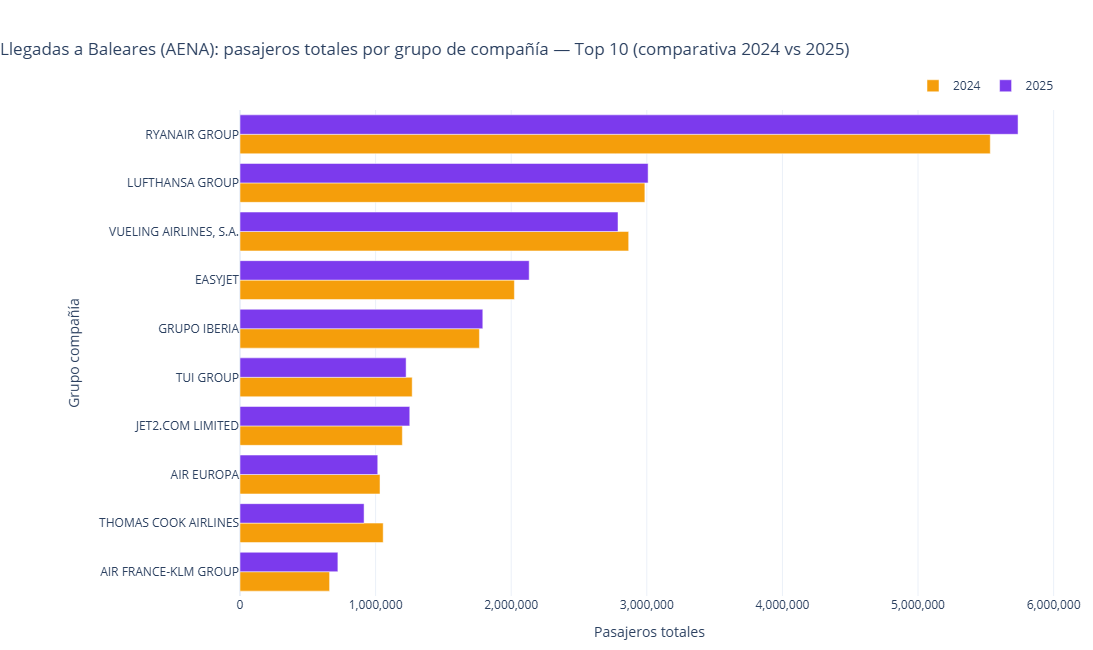

In [19]:
# Parámetros.
COLOR_2024 = "#F59E0B"
COLOR_2025 = "#7C3AED"
YEARS = [2024, 2025]
TOP_N = 10
LABEL_MAX = 28

def short_label(s: str, max_len: int = LABEL_MAX) -> str:
    s = "" if pd.isna(s) else str(s)
    return s if len(s) <= max_len else s[: max_len - 1] + "…"

# Base analítica: llegadas a Baleares (movimiento = LLEGADA)
base_df = df_baleares_llegadas.copy()

COL_GROUP  = pick_col(base_df, ["grupo_compañía", "grupo_compania", "grupo_compañia"])
COL_YEAR   = pick_col(base_df, ["año", "anio"])
COL_METRIC = pick_col(base_df, ["pasajeros_totales"])

base_df[COL_METRIC] = pd.to_numeric(base_df[COL_METRIC], errors="coerce").fillna(0)

# Agregado total (sin país)
g = (
    base_df.groupby([COL_GROUP, COL_YEAR], as_index=False)[COL_METRIC]
    .sum()
)

p = (
    g.pivot(index=COL_GROUP, columns=COL_YEAR, values=COL_METRIC)
     .fillna(0)
)

for y in YEARS:
    if y not in p.columns:
        p[y] = 0

p["total"] = p[YEARS].sum(axis=1)

top = (
    p.sort_values("total", ascending=False)
     .head(TOP_N)
)

full_names = top.index.tolist()
short_names = [short_label(x) for x in full_names]

# Invertir el eje Y para mostrar el valor mayor en la parte superior.
full_names = full_names[::-1]
short_names = short_names[::-1]
x24 = top[2024].tolist()[::-1]
x25 = top[2025].tolist()[::-1]

# Visualización.
fig = go.Figure()

fig.add_trace(go.Bar(
    y=short_names,
    x=x24,
    orientation="h",
    name="2024",
    marker_color=COLOR_2024,
    customdata=full_names,
    hovertemplate="<b>%{customdata}</b><br>2024: %{x:,.0f}<extra></extra>"
))

fig.add_trace(go.Bar(
    y=short_names,
    x=x25,
    orientation="h",
    name="2025",
    marker_color=COLOR_2025,
    customdata=full_names,
    hovertemplate="<b>%{customdata}</b><br>2025: %{x:,.0f}<extra></extra>"
))

fig.update_layout(
    title=dict(
        text=f"Llegadas a Baleares (AENA): pasajeros totales por grupo de compañía — Top {TOP_N} (comparativa 2024 vs 2025)",
        x=0.0, xanchor="left"
    ),
    template="plotly_white",
    barmode="group",
    height=650,
    xaxis_title="Pasajeros totales",
    yaxis_title="Grupo compañía",
    legend=dict(
        orientation="h",
        x=1.0, xanchor="right",
        y=1.02, yanchor="bottom"
    ),
    margin=dict(t=110, l=240, r=30, b=50)
)

fig.update_xaxes(tickformat=",")
fig.show()


### 3.3.2 Top grupos por país (selector)
Ranking de grupos para un país de origen seleccionado.

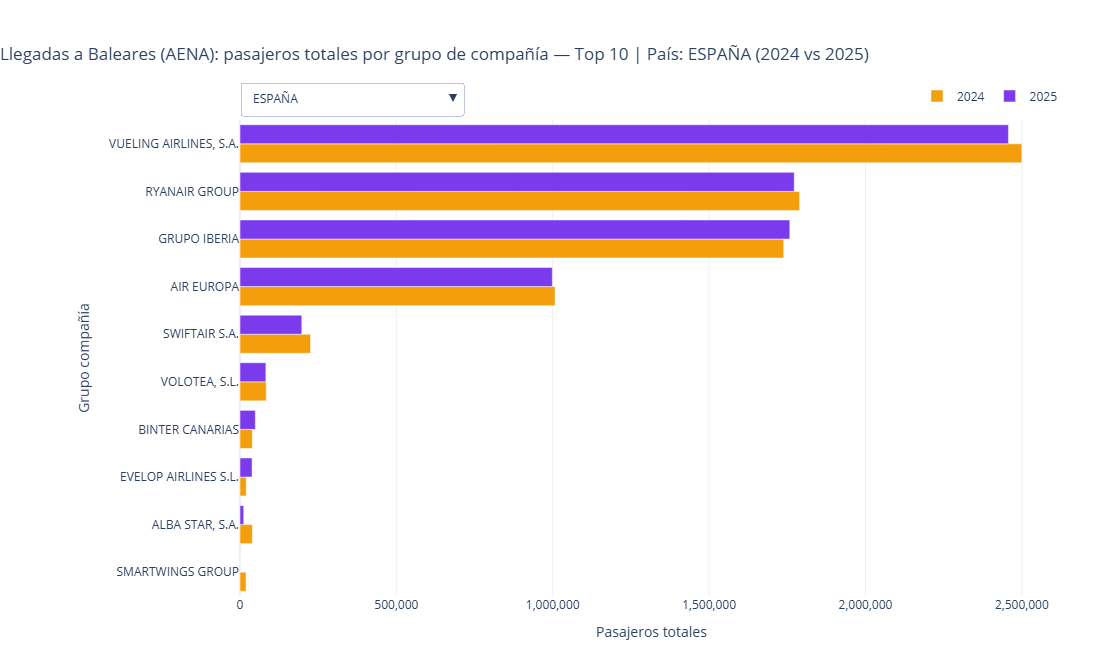

In [20]:
# Parámetros.
COLOR_2024 = "#F59E0B"
COLOR_2025 = "#7C3AED"
YEARS = [2024, 2025]
TOP_N = 10
LABEL_MAX = 28

# Funciones auxiliares.
# Base analítica: llegadas a Baleares (movimiento = LLEGADA)
base_df = df_baleares_llegadas

COL_COUNTRY = pick_col(base_df, ["país", "pais"])
COL_GROUP   = pick_col(base_df, ["grupo_compañía", "grupo_compania", "grupo_compañia"])
COL_YEAR    = pick_col(base_df, ["año", "anio"])
COL_METRIC  = pick_col(base_df, ["pasajeros_totales"])

# Preparación mínima.
base_df = base_df.copy()
base_df[COL_METRIC] = pd.to_numeric(base_df[COL_METRIC], errors="coerce").fillna(0)

countries = (
    base_df.groupby(COL_COUNTRY)[COL_METRIC].sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

if not countries:
    raise ValueError("No hay países disponibles en df_baleares_llegadas.")

def short_label(s: str, max_len: int = LABEL_MAX) -> str:
    s = "" if pd.isna(s) else str(s)
    return s if len(s) <= max_len else s[: max_len - 1] + "…"

def compute_top10_country(country: str, top_n: int = TOP_N):
    d = base_df[base_df[COL_COUNTRY] == country]

    g = (
        d.groupby([COL_GROUP, COL_YEAR], as_index=False)[COL_METRIC]
         .sum()
    )

    p = (
        g.pivot(index=COL_GROUP, columns=COL_YEAR, values=COL_METRIC)
         .fillna(0)
    )

    for y in YEARS:
        if y not in p.columns:
            p[y] = 0

    p["total"] = p[YEARS].sum(axis=1)

    top = (
        p.sort_values("total", ascending=False)
         .head(top_n)
    )

    full_names = top.index.tolist()
    short_names = [short_label(x) for x in full_names]

    full_names = full_names[::-1]
    short_names = short_names[::-1]
    x24 = top[2024].tolist()[::-1]
    x25 = top[2025].tolist()[::-1]

    return short_names, full_names, x24, x25

# Figura inicial.
country0 = countries[0]
y_short0, y_full0, x24_0, x25_0 = compute_top10_country(country0)

fig = go.Figure()

fig.add_trace(go.Bar(
    y=y_short0,
    x=x24_0,
    orientation="h",
    name="2024",
    marker_color=COLOR_2024,
    customdata=y_full0,
    hovertemplate="<b>%{customdata}</b><br>2024: %{x:,.0f}<extra></extra>"
))

fig.add_trace(go.Bar(
    y=y_short0,
    x=x25_0,
    orientation="h",
    name="2025",
    marker_color=COLOR_2025,
    customdata=y_full0,
    hovertemplate="<b>%{customdata}</b><br>2025: %{x:,.0f}<extra></extra>"
))

# Dropdown por país.
buttons = []
for c in countries:
    y_short, y_full, x24, x25 = compute_top10_country(c)
    buttons.append(dict(
        label=c,
        method="update",
        args=[
            {"y": [y_short, y_short],
             "x": [x24, x25],
             "customdata": [y_full, y_full]},
            {"title.text": f"LLEGADAS a Baleares — Top {TOP_N} grupos por pasajeros totales — País: {c}"}
        ]
    ))

fig.update_layout(
    title=dict(
        text=f"Llegadas a Baleares (AENA): pasajeros totales por grupo de compañía — Top {TOP_N} | País: {country0} (2024 vs 2025)",
        x=0.0, xanchor="left"
    ),
    template="plotly_white",
    barmode="group",
    height=650,
    xaxis_title="Pasajeros totales",
    yaxis_title="Grupo compañía",
    legend=dict(
        orientation="h",
        x=1.0, xanchor="right",
        y=1.02, yanchor="bottom"
    ),
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        x=0.0, xanchor="left",
        y=1.08, yanchor="top",
        showactive=True
    )],
    margin=dict(t=120, l=240, r=30, b=50)
)

fig.update_xaxes(tickformat=",")
fig.show()


## 4. Distribución por aeropuerto base
Participación de cada aeropuerto base en el total de llegadas.

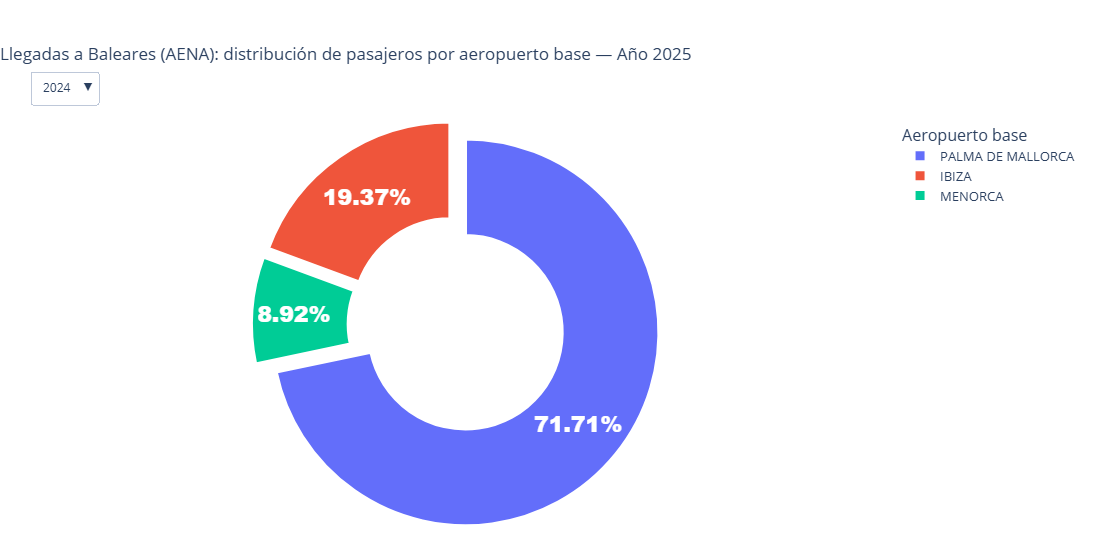

In [21]:
# Base.
base_df = df_baleares_llegadas.copy()

COL_BASE   = pick_col(base_df, ["aeropuerto_base"])
COL_YEAR   = pick_col(base_df, ["año", "anio"])
COL_METRIC = pick_col(base_df, ["pasajeros_totales"])

base_df[COL_METRIC] = pd.to_numeric(base_df[COL_METRIC], errors="coerce").fillna(0)

BASES = ["PALMA DE MALLORCA", "IBIZA", "MENORCA"]
years = sorted(base_df[COL_YEAR].dropna().unique().tolist())

def compute_share_for_year(y):
    d = base_df[base_df[COL_YEAR] == y]

    agg = (
        d.groupby(COL_BASE, as_index=False)[COL_METRIC]
         .sum()
         .set_index(COL_BASE)
         .reindex(BASES)
         .fillna(0)
         .reset_index()
    )

    return agg[COL_BASE].tolist(), agg[COL_METRIC].tolist()

# Figura inicial.
y0 = years[-1]  # Año seleccionado por defecto
labels0, values0 = compute_share_for_year(y0)

fig = go.Figure()

fig.add_trace(go.Pie(
    labels=labels0,
    values=values0,
    hole=0.50,
    pull=[0.06, 0.06, 0.06],
    textinfo="percent",
    textposition="inside",
    texttemplate="<b>%{percent:.2%}</b>",
    textfont=dict(
        size=22,
        color="white",
        family="Arial Black"
    ),
    marker=dict(
        line=dict(color="white", width=3)
    ),
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Pasajeros: %{value:,.0f}<br>"
        "Cuota: %{percent:.2%}"
        "<extra></extra>"
    )
))

# Dropdown por año.
buttons = []
for y in years:
    labels, values = compute_share_for_year(y)
    buttons.append(dict(
        label=str(y),
        method="update",
        args=[
            {"labels": [labels], "values": [values]},
            {"title.text": f"LLEGADAS a Baleares — Distribución de pasajeros por aeropuerto base ({y})"}
        ]
    ))

fig.update_layout(
    title=dict(
        text=f"Llegadas a Baleares (AENA): distribución de pasajeros por aeropuerto base — Año {y0}",
        x=0.0, xanchor="left"
    ),
    template="plotly_white",
    height=560,
    legend=dict(
        title="Aeropuerto base",
        font=dict(size=13)
    ),
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        x=0.0,
        xanchor="left",
        y=1.12,
        yanchor="top",
        showactive=True
    )],
    margin=dict(t=120, l=30, r=30, b=30)
)

fig.show()


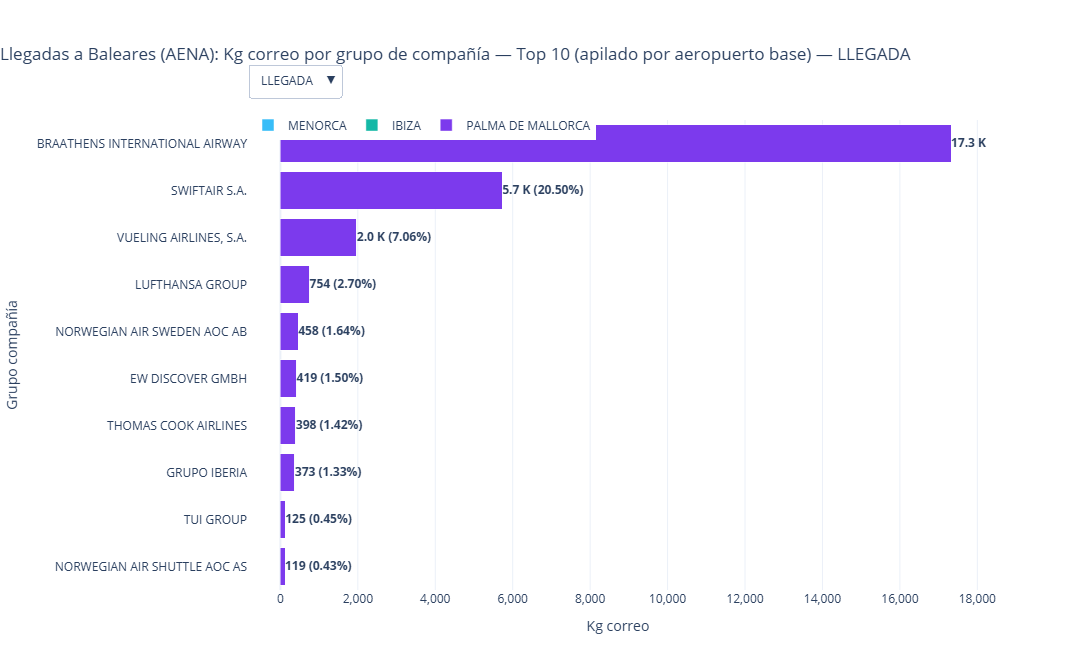

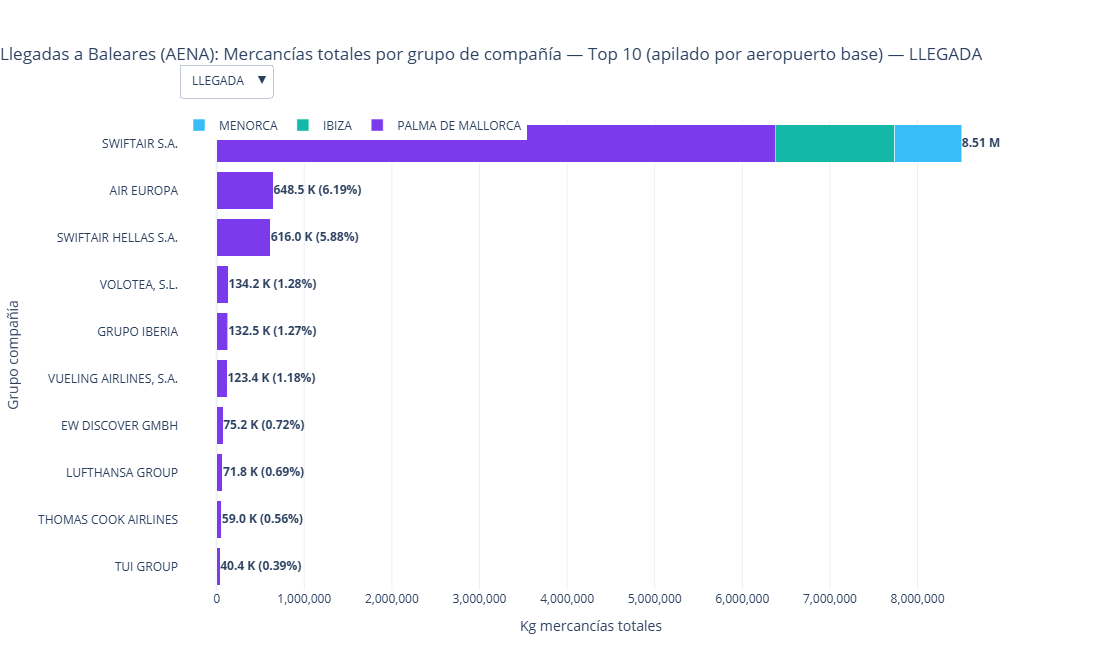

In [32]:
# Configuración.
BASES = AEROPUERTOS_BASE_BALEARES
MOVES = MOVIMIENTOS
TOP_N = 10

COLOR_PALMA   = "#7C3AED"
COLOR_IBIZA   = "#14B8A6"
COLOR_MENORCA = "#38BDF8"

def fmt_abs(x: float) -> str:
    x = float(x)
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.2f} M"
    if abs(x) >= 1_000:
        return f"{x/1_000:.1f} K"
    return f"{x:.0f}"

# Columnas (robustas a tildes)
COL_BASE   = pick_col(df_baleares, ["aeropuerto_base"])
COL_MOVE   = pick_col(df_baleares, ["movimiento"])
COL_GROUP  = pick_col(df_baleares, ["grupo_compañía", "grupo_compania", "grupo_compañia"])

COL_CORREO = pick_col(df_baleares, ["kg_correo"])
COL_MERC   = pick_col(df_baleares, ["mercancías_totales", "mercancias_totales"])

# Asegurar columnas numéricas.
df_baleares = df_baleares.copy()
for c in [COL_CORREO, COL_MERC]:
    df_baleares[c] = pd.to_numeric(df_baleares[c], errors="coerce").fillna(0)

# Preparación de datos para indicador (correo o mercancías)
def prepare_top10_stacked(df, metric_col, movement, top_n=TOP_N):
    d = df[df[COL_MOVE] == movement].copy()

    total_all = d[metric_col].sum()

    grp_total = (
        d.groupby(COL_GROUP, as_index=False)[metric_col]
         .sum()
         .rename(columns={metric_col: "total"})
         .sort_values("total", ascending=False)
    )

    top_groups = grp_total.head(top_n)[COL_GROUP].tolist()

    stacked = (
        d[d[COL_GROUP].isin(top_groups)]
        .groupby([COL_GROUP, COL_BASE], as_index=False)[metric_col]
        .sum()
        .rename(columns={metric_col: "value"})
    )

    p = (
        stacked.pivot(index=COL_GROUP, columns=COL_BASE, values="value")
               .fillna(0)
    )

    for b in BASES:
        if b not in p.columns:
            p[b] = 0

    p["total"] = p[BASES].sum(axis=1)
    p = p.sort_values("total", ascending=False)

    p["pct_total"] = ((p["total"] / total_all) * 100).round(2) if total_all else 0.0
    p["label"] = p.apply(lambda r: f"{fmt_abs(r['total'])} ({r['pct_total']:.2f}%)", axis=1)

    # En horizontal: categorías en Y
    y = p.index.tolist()
    x_palma = p["PALMA DE MALLORCA"].tolist()
    x_ibiza = p["IBIZA"].tolist()
    x_menorca = p["MENORCA"].tolist()
    x_total = p["total"].tolist()
    labels = p["label"].tolist()

    return y, x_palma, x_ibiza, x_menorca, x_total, labels, total_all

def build_stacked_chart(metric_col, metric_name, unit_label):

    pre = {}
    for m in MOVES:
        pre[m] = prepare_top10_stacked(df_baleares, metric_col, m, TOP_N)

    m0 = MOVES[0]
    y, x_palma, x_ibiza, x_menorca, x_total, labels, total_all = pre[m0]

    fig = go.Figure()

    fig.add_trace(go.Bar(
        name="PALMA DE MALLORCA",
        y=y, x=x_palma,
        orientation="h",
        marker_color=COLOR_PALMA,
        hovertemplate="<b>%{y}</b><br>Palma: %{x:,.0f}<extra></extra>"
    ))
    fig.add_trace(go.Bar(
        name="IBIZA",
        y=y, x=x_ibiza,
        orientation="h",
        marker_color=COLOR_IBIZA,
        hovertemplate="<b>%{y}</b><br>Ibiza: %{x:,.0f}<extra></extra>"
    ))
    fig.add_trace(go.Bar(
        name="MENORCA",
        y=y, x=x_menorca,
        orientation="h",
        marker_color=COLOR_MENORCA,
        hovertemplate="<b>%{y}</b><br>Menorca: %{x:,.0f}<extra></extra>"
    ))

    fig.add_trace(go.Scatter(
        x=x_total,
        y=y,
        mode="text",
        text=[f"<b>{t}</b>" for t in labels],
        textposition="middle right",
        hoverinfo="skip",
        showlegend=False
    ))

    buttons = []
    for m in MOVES:
        y, x_palma, x_ibiza, x_menorca, x_total, labels, total_all = pre[m]
        buttons.append(dict(
            label=m,
            method="update",
            args=[
                {
                    "y": [y, y, y, y],
                    "x": [x_palma, x_ibiza, x_menorca, x_total],
                    "text": [None, None, None, [f"<b>{t}</b>" for t in labels]],
                },
                {
                    "title.text": (
                        f"Baleares — Top {TOP_N} grupos por {metric_name} ({m}) "
                        f"— etiqueta = total y % sobre el total"
                    ),
                    "xaxis.title": unit_label
                }
            ]
        ))

    fig.update_layout(
        title=dict(
            text=f"Llegadas a Baleares (AENA): {metric_name} por grupo de compañía — Top {TOP_N} (apilado por aeropuerto base) — {m0}",
            x=0.0, xanchor="left"
        ),
        template="plotly_white",
        barmode="stack",
        height=650,
        xaxis_title=unit_label,
        yaxis_title="Grupo compañía",
        legend=dict(orientation="h", x=0.0, y=1.02),
        updatemenus=[dict(
            buttons=buttons,
            direction="down",
            x=0.0, xanchor="left",
            y=1.12, yanchor="top",
            showactive=True
        )],
        margin=dict(t=120, l=70, r=90, b=60)
    )

    fig.update_xaxes(tickformat=",")
    fig.update_yaxes(autorange="reversed")
    return fig

# Gráfico: Kg correo.
fig_correo = build_stacked_chart(
    metric_col=COL_CORREO,
    metric_name="Kg correo",
    unit_label="Kg correo"
)
fig_correo.show()

# Gráfico: Mercancías totales.
fig_merc = build_stacked_chart(
    metric_col=COL_MERC,
    metric_name="Mercancías totales",
    unit_label="Kg mercancías totales"
)
fig_merc.show()


## 5. Evolución mensual
Series temporales mensuales (total Baleares y detalle).

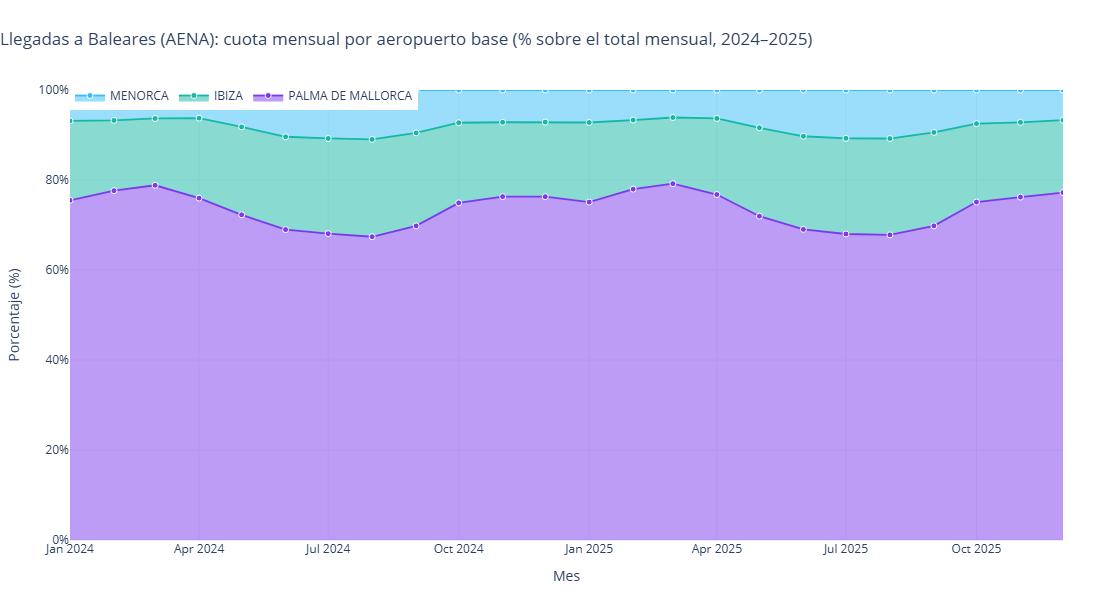

In [23]:
BASES = AEROPUERTOS_BASE_BALEARES
# Base.
d = df_baleares_llegadas.copy()

COL_BASE   = pick_col(d, ["aeropuerto_base"])
COL_METRIC = pick_col(d, ["pasajeros_totales"])
COL_DATE   = pick_col(d, ["fecha"])

# Numérico.
d[COL_METRIC] = pd.to_numeric(d[COL_METRIC], errors="coerce").fillna(0)

# Asegurar que fecha sea datetime.
d[COL_DATE] = pd.to_datetime(d[COL_DATE], errors="coerce")
d = d.dropna(subset=[COL_DATE])

# Agregado mensual por aeropuerto.
g = (
    d.groupby([COL_DATE, COL_BASE], as_index=False)[COL_METRIC]
     .sum()
)

# Pivot: filas=mes, columnas=aeropuerto_base.
p = (
    g.pivot(index=COL_DATE, columns=COL_BASE, values=COL_METRIC)
     .fillna(0)
)

# Asegurar las 3 bases.
for b in BASES:
    if b not in p.columns:
        p[b] = 0

p = p[BASES].sort_index()

# Total baleares por mes (para % y hover)
p["total_mes"] = p.sum(axis=1)

# Porcentaje por base (para hover)
pct = (p[BASES].div(p["total_mes"].replace(0, pd.NA), axis=0) * 100).fillna(0).round(2)

# Figura: stacked area 100%.
fig = go.Figure()

colors = {
    "PALMA DE MALLORCA": "#7C3AED",
    "IBIZA": "#14B8A6",
    "MENORCA": "#38BDF8",
}

for b in BASES:
    custom = list(zip(
        p[b].tolist(),
        pct[b].tolist(),
        p["total_mes"].tolist()
    ))

    fig.add_trace(go.Scatter(
        x=p.index,
        y=p[b],
        mode="lines+markers",
        name=b,
        stackgroup="one",
        groupnorm="percent",
        line=dict(width=1.8),
        marker=dict(
            size=6,
            symbol="circle",
            line=dict(width=1, color="white")
        ),
        marker_color=colors.get(b),
        customdata=custom,
        hovertemplate=(
            "<b>%{x|%b %Y}</b><br>"
            f"{b}<br>"
            "<b>%{customdata[1]:.2f}%</b><br>"
            "Abs: %{customdata[0]:,.0f}<br>"
            "Total mes (Baleares): %{customdata[2]:,.0f}"
            "<extra></extra>"
        )
    ))

fig.update_layout(
    title=dict(
        text="Llegadas a Baleares (AENA): cuota mensual por aeropuerto base (% sobre el total mensual, 2024–2025)",
        x=0.0, xanchor="left"
    ),
    template="plotly_white",
    height=600,
    xaxis_title="Mes",
    yaxis_title="Porcentaje (%)",
    hovermode="x unified",
    legend=dict(orientation="h", x=0.0, y=1.02),
    margin=dict(t=90, l=70, r=30, b=60)
)

fig.update_yaxes(ticksuffix="%", range=[0, 100])
fig.show()


## 6. Temporada alta vs baja
Comparativa interanual (2025 vs 2024) separando temporada alta (mayo–septiembre) y baja (resto).

In [24]:
# Preparación de datos para indicador (correo o mercancías)
# Agregamos pasajeros por (año, temporada) a partir de llegadas.
d = df_baleares_llegadas.copy()

COL_DATE = pick_col(d, ["fecha"])
COL_MET  = pick_col(d, ["pasajeros_totales"])

d[COL_DATE] = pd.to_datetime(d[COL_DATE], errors="coerce")
d[COL_MET]  = pd.to_numeric(d[COL_MET], errors="coerce").fillna(0)
d = d.dropna(subset=[COL_DATE]).copy()

d["año"] = d[COL_DATE].dt.year
d["mes"] = d[COL_DATE].dt.month
d["temporada"] = np.where(d["mes"].isin(MESES_ALTA), "Alta", "Baja")

agg = (
    d[d["año"].isin(YEARS)]
    .groupby(["año", "temporada"], as_index=False)["pasajeros_totales"]
    .sum()
)

def calc_variacion(df: pd.DataFrame, temporada: str):
    """Variación % 2025 vs 2024 para una temporada dada."""
    v2024 = df.loc[(df["año"] == 2024) & (df["temporada"] == temporada), "pasajeros_totales"].sum()
    v2025 = df.loc[(df["año"] == 2025) & (df["temporada"] == temporada), "pasajeros_totales"].sum()

    if v2024 == 0:
        return None, v2024, v2025

    var_pct = (v2025 - v2024) / v2024 * 100
    return round(var_pct, 2), v2024, v2025

var_alta, alta_2024, alta_2025 = calc_variacion(agg, "Alta")
var_baja, baja_2024, baja_2025 = calc_variacion(agg, "Baja")

var_alta, var_baja


(np.float64(0.77), np.float64(2.24))

In [25]:
def kpi_card(title, var_pct):
    if var_pct is None:
        color = "gray"
        symbol = ""
        value = 0
    else:
        symbol = "▲" if var_pct >= 0 else "▼"
        color = "#16A34A" if var_pct >= 0 else "#DC2626"
        value = abs(var_pct)

    fig = go.Figure()

    fig.add_trace(go.Indicator(
        mode="number",
        value=value,
        number=dict(
            suffix="%",
            valueformat=".2f",
            font=dict(size=46, color=color)
        ),
        title=dict(
            text=f"<b>{title}</b><br><span style='font-size:14px'>2025 vs 2024</span>"
        ),
        domain={"x": [0, 1], "y": [0, 1]}
    ))

    fig.add_annotation(
        text=symbol,
        x=0.43,
        y=0.52,
        showarrow=False,
        font=dict(size=40, color=color),
        xanchor="right",
        yanchor="middle"
    )

    fig.update_layout(
        height=220,
        margin=dict(t=40, b=20, l=20, r=20),
        template="plotly_white"
    )

    return fig

fig_alta = kpi_card("Temporada Alta", var_alta)
fig_baja = kpi_card("Temporada Baja", var_baja)


### 6.1 Temporada alta (mayo–septiembre)
Indicador de variación % interanual de pasajeros totales.

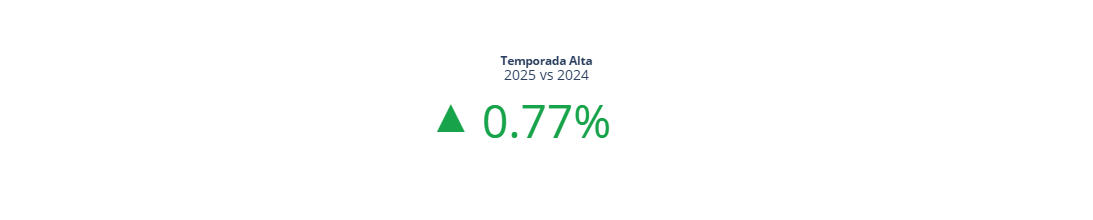

In [26]:
fig_alta.show()


### 6.2 Temporada baja (octubre–abril)
Indicador de variación % interanual de pasajeros totales.

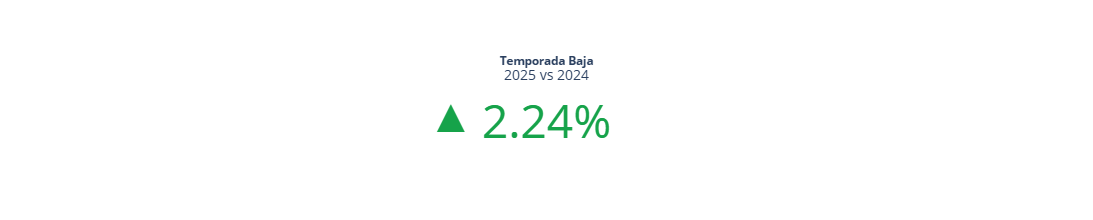

In [27]:
fig_baja.show()


### 6.3 Indicador de estacionalidad (IEA)
Relación entre el promedio mensual de temporada alta y el promedio mensual anual.

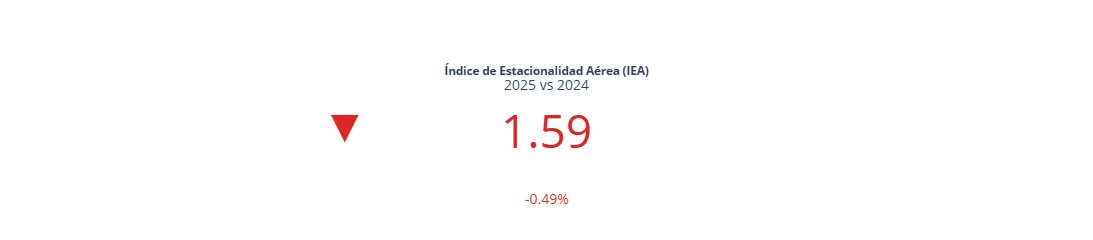

In [28]:
# Base.
d = df_baleares_llegadas.copy()

COL_DATE = pick_col(d, ["fecha"])
COL_MET  = pick_col(d, ["pasajeros_totales"])

d[COL_DATE] = pd.to_datetime(d[COL_DATE], errors="coerce")
d[COL_MET]  = pd.to_numeric(d[COL_MET], errors="coerce").fillna(0)
d = d.dropna(subset=[COL_DATE])

d["año"] = d[COL_DATE].dt.year
d["mes"] = d[COL_DATE].dt.month
d["temporada"] = d["mes"].apply(lambda m: "Alta" if m in MESES_ALTA else "Baja")

# Total mensual Baleares (para promedios mensuales)
ts = (
    d.groupby([COL_DATE, "año", "mes", "temporada"], as_index=False)[COL_MET]
     .sum()
)

def iea_for_year(year: int):
    x = ts[ts["año"] == year].copy()
    if x.empty:
        return None

    avg_year = x[COL_MET].mean()  # Promedio mensual del año (meses disponibles)
    avg_high = x.loc[x["temporada"] == "Alta", COL_MET].mean()

    if avg_year == 0 or pd.isna(avg_year) or pd.isna(avg_high):
        return None

    return avg_high / avg_year

iea_2024 = iea_for_year(2024)
iea_2025 = iea_for_year(2025)

# Variación % del índice (2025 vs 2024)
var_pct = None
if iea_2024 not in (None, 0) and iea_2025 is not None:
    var_pct = (iea_2025 - iea_2024) / iea_2024 * 100

# KPI Visual.
def kpi_indicator_with_triangle(title, value, var_pct):
    if value is None:
        value = 0
        symbol = ""
        color = "gray"
    else:
        symbol = "▲" if (var_pct is not None and var_pct >= 0) else "▼"
        color  = "#16A34A" if (var_pct is not None and var_pct >= 0) else "#DC2626"

    fig = go.Figure()

    fig.add_trace(go.Indicator(
        mode="number",
        value=value if value is not None else 0,
        number=dict(valueformat=".2f", font=dict(size=46, color=color)),
        title=dict(text=f"<b>{title}</b><br><span style='font-size:14px'>2025 vs 2024</span>"),
        domain={"x": [0, 1], "y": [0, 1]}
    ))

    fig.add_annotation(
        text=symbol if var_pct is not None else "",
        x=0.33, y=0.52,
        showarrow=False,
        font=dict(size=40, color=color),
        xanchor="right", yanchor="middle"
    )

    if var_pct is not None:
        fig.add_annotation(
            text=f"{var_pct:+.2f}%",
            x=0.5, y=0.12,
            showarrow=False,
            font=dict(size=14, color=color),
            xanchor="center", yanchor="middle"
        )

    fig.update_layout(height=240, margin=dict(t=40, b=20, l=20, r=20), template="plotly_white")
    return fig

fig_iea = kpi_indicator_with_triangle(
    "Índice de Estacionalidad Aérea (IEA)",
    iea_2025,
    var_pct
)

fig_iea.show()


### 6.4 Concentración por país (HHI)
Índice de concentración (Herfindahl–Hirschman) calculado sobre la distribución de pasajeros por país.

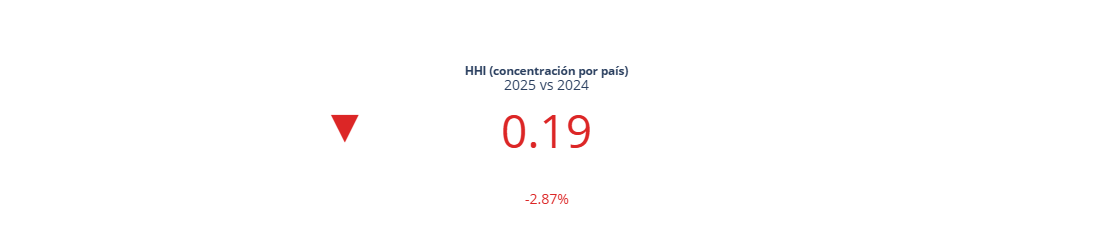

In [29]:
# Base.
d = df_baleares_llegadas.copy()

COL_DATE = pick_col(d, ["fecha"])
COL_MET  = pick_col(d, ["pasajeros_totales"])
COL_PAIS = pick_col(d, ["país", "pais"])

d[COL_DATE] = pd.to_datetime(d[COL_DATE], errors="coerce")
d[COL_MET]  = pd.to_numeric(d[COL_MET], errors="coerce").fillna(0)
d = d.dropna(subset=[COL_DATE])

d["año"] = d[COL_DATE].dt.year

def hhi_for_year(year: int):
    x = d[d["año"] == year].copy()
    if x.empty:
        return None, None

    by_country = x.groupby(COL_PAIS, as_index=False)[COL_MET].sum()
    total = by_country[COL_MET].sum()
    if total == 0:
        return None, by_country

    by_country["share"] = by_country[COL_MET] / total
    hhi = (by_country["share"] ** 2).sum()
    return float(hhi), by_country

hhi_2024, c2024 = hhi_for_year(2024)
hhi_2025, c2025 = hhi_for_year(2025)

var_pct_hhi = None
if hhi_2024 not in (None, 0) and hhi_2025 is not None:
    var_pct_hhi = (hhi_2025 - hhi_2024) / hhi_2024 * 100

fig_hhi = kpi_indicator_with_triangle(
    "HHI (concentración por país)",
    hhi_2025,
    var_pct_hhi
)
fig_hhi.show()


## 7. Ranking mensual por grupo
Evolución del ranking mensual de los principales grupos por volumen de pasajeros.

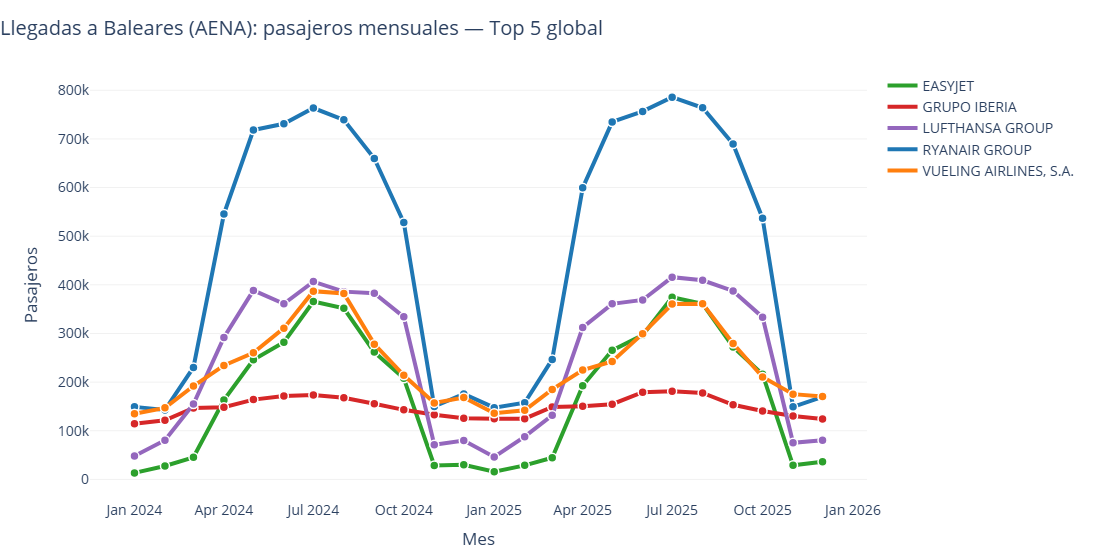

In [49]:
import pandas as pd
import plotly.graph_objects as go

TOP_N = 5

# ----------------------------
# Colores FIJOS por grupo
# ----------------------------
FIXED_COLORS = {
    "VUELING AIRLINES, S.A.": "#ff7f0e",   # naranja
    "RYANAIR GROUP": "#1f77b4",            # azul
}

# Paleta de respaldo
FALLBACK_PALETTE = [
    "#2ca02c",  # verde
    "#d62728",  # rojo
    "#9467bd",  # violeta
    "#8c564b",  # marrón
]

LINE_WIDTH = 4
BULLET_SIZE = 9
BULLET_LINE_WIDTH = 1.5


# ----------------------------
# 1) Preparación de datos
# ----------------------------
d = df_baleares_llegadas.copy()

COL_DATE  = pick_col(d, ["fecha"])
COL_MET   = pick_col(d, ["pasajeros_totales"])
COL_GROUP = pick_col(d, ["grupo_compañía", "grupo_compania", "grupo_compañia"])

d[COL_DATE] = pd.to_datetime(d[COL_DATE], errors="coerce")
d[COL_MET]  = pd.to_numeric(d[COL_MET], errors="coerce").fillna(0)
d = d.dropna(subset=[COL_DATE])

# Normalizar a mes
d[COL_DATE] = d[COL_DATE].dt.to_period("M").dt.to_timestamp()

# Agregado mensual
g = (
    d.groupby([COL_DATE, COL_GROUP], as_index=False)[COL_MET]
     .sum()
)

# ----------------------------
# 2) Top N GLOBAL del periodo
# ----------------------------
top_global = (
    g.groupby(COL_GROUP)[COL_MET].sum()
     .sort_values(ascending=False)
     .head(TOP_N)
     .index
)

top = g[g[COL_GROUP].isin(top_global)].copy()
top = top.sort_values([COL_GROUP, COL_DATE])

groups = top[COL_GROUP].unique().tolist()

# ----------------------------
# 3) Asignación de colores
# ----------------------------
color_map = {}
fallback_idx = 0

for grp in groups:
    if grp in FIXED_COLORS:
        color_map[grp] = FIXED_COLORS[grp]
    else:
        color_map[grp] = FALLBACK_PALETTE[fallback_idx % len(FALLBACK_PALETTE)]
        fallback_idx += 1


# ----------------------------
# 4) Figura: líneas + bullets
#    (evitar duplicación en hover: SOLO el trace de markers tiene hover)
# ----------------------------
fig = go.Figure()

for grp in groups:
    s = top[top[COL_GROUP] == grp].sort_values(COL_DATE)
    color = color_map[grp]

    # Línea (SIN hover, así no duplica en x unified)
    fig.add_trace(go.Scatter(
        x=s[COL_DATE],
        y=s[COL_MET],
        mode="lines",
        name=str(grp),  # aparece en la leyenda
        line=dict(width=LINE_WIDTH, color=color),
        hoverinfo="skip",          # <- clave: no aporta tooltip
        showlegend=True
    ))

    # Bullets (CON hover)
    fig.add_trace(go.Scatter(
        x=s[COL_DATE],
        y=s[COL_MET],
        mode="markers",
        name=str(grp),
        showlegend=False,          # no duplicar leyenda
        marker=dict(
            size=BULLET_SIZE,
            color=color,
            line=dict(width=BULLET_LINE_WIDTH, color="white")
        ),
        hovertemplate=(
            "<b>%{x|%b %Y}</b><br>"
            f"{grp}<br>"
            "Pasajeros: %{y:,.0f}"
            "<extra></extra>"
        ),
    ))

# ----------------------------
# 5) Layout
# ----------------------------
fig.update_layout(
    title=dict(
        text=f"Llegadas a Baleares (AENA): pasajeros mensuales — Top {TOP_N} global",
        x=0.0, xanchor="left"
    ),
    template="plotly_white",
    height=560,
    margin=dict(t=70, l=90, r=180, b=60),
    xaxis_title="Mes",
    yaxis_title="Pasajeros",
    hovermode="x unified",
    legend=dict(
        orientation="v",
        y=1,
        x=1.02,
        title=None
    ),
    font=dict(size=14),
)

fig.update_xaxes(
    dtick="M3",
    tickformat="%b %Y",
    showgrid=False
)

fig.update_yaxes(
    gridcolor="rgba(0,0,0,0.06)",
    zeroline=False
)

fig.show()

# Export recomendado:
# fig.write_image("line_bullets_top5_global.svg")
# fig.write_image("line_bullets_top5_global.png", scale=3)


## 8. Estacionalidad (mapa de calor)

Se normaliza cada aeropuerto base por su mes de máximo volumen para comparar la **forma estacional** (0–100%), evitando que el tamaño absoluto domine la lectura.


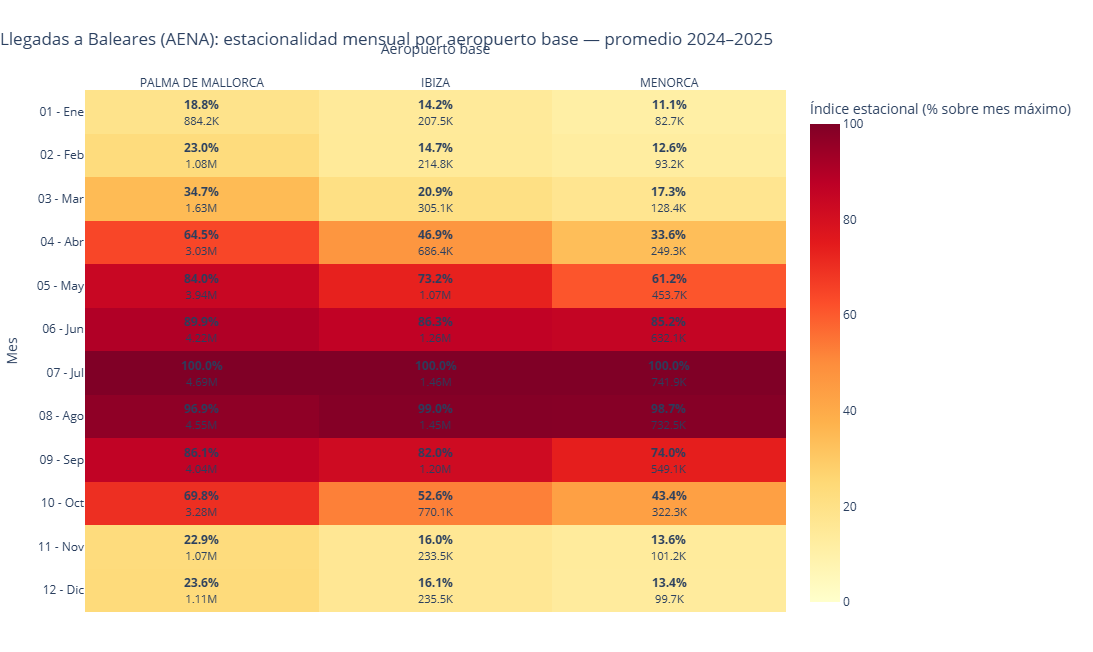

In [31]:
# Base.
d = df_baleares_llegadas.copy()

COL_BASE = pick_col(d, ["aeropuerto_base"])
COL_DATE = pick_col(d, ["fecha"])
COL_MET  = pick_col(d, ["pasajeros_totales"])

# Se asume que 'fecha' y 'pasajeros_totales' ya están tipados en la fase de preparación.
d = d.dropna(subset=[COL_DATE]).copy()

d["mes_num"] = d[COL_DATE].dt.month
d["año"] = d[COL_DATE].dt.year

BASES = AEROPUERTOS_BASE_BALEARES

# Agregado: promedio mensual 2024–2025 por aeropuerto base.
p_abs = (
    d[d[COL_BASE].isin(BASES)]
    .groupby(["mes_num", COL_BASE], as_index=False)[COL_MET]
    .sum()
    .pivot(index="mes_num", columns=COL_BASE, values=COL_MET)
    .fillna(0)
)

# Asegurar 12 meses y las 3 columnas.
for b in BASES:
    if b not in p_abs.columns:
        p_abs[b] = 0
p_abs = p_abs[BASES].reindex(range(1, 13)).fillna(0)

# Normalización por aeropuerto (columna)
# Cada aeropuerto: su mes máximo = 100% (comparabilidad de estacionalidad)
col_max = p_abs.max(axis=0).replace(0, pd.NA)
p_pct = (p_abs.div(col_max, axis=1) * 100).fillna(0)

mes_labels = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}
y_labels = [f"{m:02d} - {mes_labels[m]}" for m in p_abs.index]

# Texto por celda: % (normalizado) + valor absoluto.
cell_text = []
cell_custom = []
for m in p_abs.index:
    row_text = []
    row_custom = []
    for b in BASES:
        pct = float(p_pct.loc[m, b])
        abs_val = float(p_abs.loc[m, b])
        row_text.append(f"<b>{pct:.1f}%</b><br><span style='font-size:11px'>{fmt_short(abs_val)}</span>")
        row_custom.append(f"{fmt_short(abs_val)} pasajeros")
    cell_text.append(row_text)
    cell_custom.append(row_custom)

# Heatmap.
cell_height_px = 36
height = 220 + cell_height_px * 12

fig = go.Figure(
    data=go.Heatmap(
        z=p_pct.values,
        x=BASES,
        y=y_labels,
        colorscale="YlOrRd",
        zmin=0,
        zmax=100,
        customdata=cell_custom,
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Aeropuerto base: <b>%{x}</b><br>"
            "Índice estacional: <b>%{z:.1f}%</b> (vs. mes máximo del aeropuerto)<br>"
            "Promedio mensual: %{customdata}<extra></extra>"
        ),
        colorbar=dict(title="Índice estacional (% sobre mes máximo)")
    )
)

# Anotaciones (texto dentro de cada celda)
annotations = []
for i_m, y in enumerate(y_labels):
    for j_b, b in enumerate(BASES):
        annotations.append(
            dict(
                x=b, y=y,
                text=cell_text[i_m][j_b],
                showarrow=False,
                xref="x",
                yref="y",
                align="center"
            )
        )

fig.update_layout(
    title=dict(
        text="Llegadas a Baleares (AENA): estacionalidad mensual por aeropuerto base — promedio 2024–2025",
        x=0.0,
        xanchor="left"
    ),
    template="plotly_white",
    height=height,
    margin=dict(t=90, l=80, r=40, b=40),
    annotations=annotations,
    xaxis_title="Aeropuerto base",
    yaxis_title="Mes"
)

fig.update_xaxes(side="top")
fig.update_yaxes(autorange="reversed")

fig.show()
